In [1]:
#Importations
from pulp import * # type: ignore
import pandas as pd

In [2]:
#Chargement de la table de données
demande_data = pd.read_excel("case_study3.xlsx",sheet_name="Demandes",index_col='Modèles')
other_data = pd.read_excel("case_study3.xlsx",sheet_name="DonneesSup", index_col='Modèles')
demande_data = demande_data.transpose() #J'ai inversé dans le fichier excel
demande_data

Modèles,1,2,3,4,5,6,7,8,9,10,11,12
V1,20,22,18,25,17,19,23,20,29,30,28,32
V2,17,19,33,25,23,26,9,22,27,11,29,30
V3,18,35,21,23,15,17,22,17,23,15,27,22
V4,31,45,25,20,27,29,17,28,36,33,24,12
V5,23,20,37,22,24,20,40,31,34,18,23,30
V6,22,18,10,25,30,12,25,32,24,40,28,34


In [4]:
#Paramètres
weeks = list(range(1,13))
verres = list(other_data.index)

verres,weeks

(['V1', 'V2', 'V3', 'V4', 'V5', 'V6'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

In [5]:
#Initialisation du modèle
model = LpProblem("Minimize_production_and_inventory_overall_cost",LpMinimize)

In [6]:
#Définition des variables de décision
prod_i_j = LpVariable.dicts(name='Production_',indices=[(i,j) for i in verres for j in weeks],lowBound=0,cat=LpInteger)
stock_i_j = LpVariable.dicts(name='Stockage_',indices=[(i,j) for i in verres for j in weeks],lowBound=0,cat=LpInteger)

In [7]:
#Définition de la fonction objectif
model += (lpSum([other_data.loc[i,'CoutProd']*prod_i_j[i,j] for j in weeks for i in verres])+lpSum([other_data.loc[i,'CoutStock']*stock_i_j[i,j] for j in weeks for i in verres]))

In [8]:
#Définition des contraintes

#Capacité en TH
for j in weeks:
    model += lpSum([other_data.loc[i,'TH']*prod_i_j[i,j] for i in verres])<=469 #390

#Capacité en TM
for j in weeks:
    model += lpSum([other_data.loc[i,'TM']*prod_i_j[i,j] for i in verres])<=914 #850

#Capacité en TS
for j in weeks:
    model += lpSum([other_data.loc[i,'TS']*stock_i_j[i,j] for i in verres])<=1000

#Synchronisation stocks-production-demande
for i in verres:
    model += stock_i_j[i,1] == other_data.loc[i,'StockInitial']+prod_i_j[i,1]-demande_data.loc[i,1]
    # other_data.loc[i,'StockInitial']
    for j in weeks[1:]:
        model += stock_i_j[i,j] == stock_i_j[i,j-1]+prod_i_j[i,j]-demande_data.loc[i,j]
    #Stocks finaux positifs ou nuls à chaque fin de semaine (à une exception près)
    model += stock_i_j[i,3]==other_data.loc[i,'StockFinal']


In [9]:
#Résolution du modèle
model.solve() # type: ignore

1

In [10]:
#Rapport

print(f"Coût global : {value(model.objective)}$")
print("Status : ",LpStatus[model.status])
production = pd.DataFrame({j:[value(prod_i_j[i,j]) for i in verres] for j in weeks},index=verres)
stocks = pd.DataFrame({j:[value(stock_i_j[i,j]) for i in verres] for j in weeks},index=verres)
production

Coût global : 210504.0$
Status :  Optimal


,1,2,3,4,5,6,7,8,9,10,11,12
V1,0.0,8.0,12.0,15.0,17.0,19.0,23.0,24.0,25.0,31.0,27.0,32.0
V2,0.0,16.0,43.0,15.0,23.0,26.0,9.0,22.0,27.0,16.0,24.0,30.0
V3,18.0,35.0,31.0,13.0,15.0,17.0,22.0,17.0,23.0,15.0,28.0,21.0
V4,16.0,45.0,35.0,10.0,27.0,29.0,17.0,28.0,36.0,33.0,24.0,12.0
V5,55.0,20.0,15.0,37.0,28.0,40.0,37.0,24.0,19.0,13.0,19.0,15.0
V6,12.0,18.0,20.0,15.0,30.0,12.0,25.0,32.0,24.0,41.0,27.0,34.0


In [12]:
stocks

,1,2,3,4,5,6,7,8,9,10,11,12
V1,30.0,16.0,10.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,0.0
V2,3.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0
V3,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
V4,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
V5,32.0,32.0,10.0,25.0,29.0,49.0,46.0,39.0,24.0,19.0,15.0,0.0
V6,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [13]:
o = [{'Contraintes':nom,"Cout dual":c.pi,"écart":int(c.slack)} for nom, c in model.constraints.items()]
sens_df = pd.DataFrame(o)
sens_df

,Contraintes,Cout dual,écart
0,_C1,0.0,115
1,_C2,0.0,50
2,_C3,0.0,1
3,_C4,0.0,112
4,_C5,0.0,18
...,...,...,...
109,_C110,0.0,0
110,_C111,0.0,0
111,_C112,0.0,0
112,_C113,0.0,0


In [14]:
model.constraints

{'_C1': 3*Production__('V1',_1) + 3*Production__('V2',_1) + 3*Production__('V3',_1) + 2*Production__('V4',_1) + 4*Production__('V5',_1) + 4*Production__('V6',_1) + -469.0 <= 0,
 '_C2': 3*Production__('V1',_2) + 3*Production__('V2',_2) + 3*Production__('V3',_2) + 2*Production__('V4',_2) + 4*Production__('V5',_2) + 4*Production__('V6',_2) + -469.0 <= 0,
 '_C3': 3*Production__('V1',_3) + 3*Production__('V2',_3) + 3*Production__('V3',_3) + 2*Production__('V4',_3) + 4*Production__('V5',_3) + 4*Production__('V6',_3) + -469.0 <= 0,
 '_C4': 3*Production__('V1',_4) + 3*Production__('V2',_4) + 3*Production__('V3',_4) + 2*Production__('V4',_4) + 4*Production__('V5',_4) + 4*Production__('V6',_4) + -469.0 <= 0,
 '_C5': 3*Production__('V1',_5) + 3*Production__('V2',_5) + 3*Production__('V3',_5) + 2*Production__('V4',_5) + 4*Production__('V5',_5) + 4*Production__('V6',_5) + -469.0 <= 0,
 '_C6': 3*Production__('V1',_6) + 3*Production__('V2',_6) + 3*Production__('V3',_6) + 2*Production__('V4',_6) + 4*P

## PHASE 1 : Analyse des distributions de la demande

Nous allons analyser les données historiques de demande pour trouver une distribution qui s'ajuste bien pour chaque modèle de verre.

In [15]:
#Importations supplémentaires pour l'analyse de distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from scipy.stats import kstest, shapiro, norm, gamma, lognorm, weibull_min, expon

# Configuration for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

STATISTIQUES DESCRIPTIVES DE LA DEMANDE PAR MODÈLE

Données de demande (12 périodes) :
Modèles  1   2   3   4   5   6   7   8   9   10  11  12
V1       20  22  18  25  17  19  23  20  29  30  28  32
V2       17  19  33  25  23  26   9  22  27  11  29  30
V3       18  35  21  23  15  17  22  17  23  15  27  22
V4       31  45  25  20  27  29  17  28  36  33  24  12
V5       23  20  37  22  24  20  40  31  34  18  23  30
V6       22  18  10  25  30  12  25  32  24  40  28  34

Statistiques par modèle de verre :
         Moyenne  Écart-type  Minimum  Maximum  Médiane  \
Modèles                                                   
1         21.833       5.037       17       31     21.0   
2         26.500      11.005       18       45     21.0   
3         24.000       9.920       10       37     23.0   
4         23.333       2.066       20       25     24.0   
5         22.667       5.750       15       30     23.5   
6         20.500       6.156       12       29     19.5   
7         22.

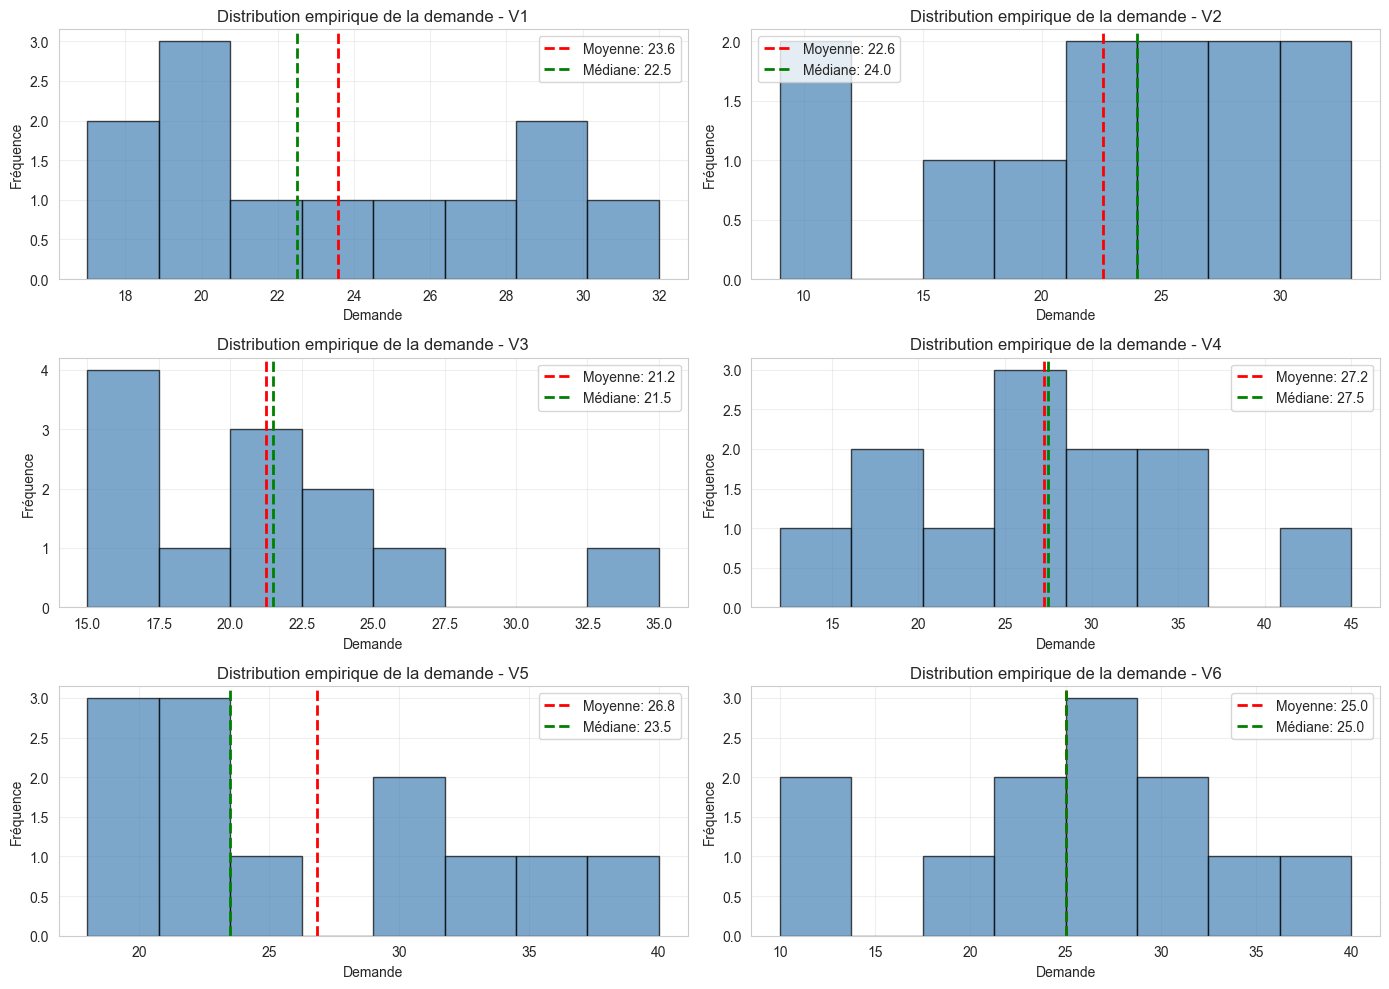


Observation : Les données historiques montrent la variabilité de la demande pour chaque modèle.


In [17]:
# Analyse descriptive de la demande par modèle
print("="*70)
print("STATISTIQUES DESCRIPTIVES DE LA DEMANDE PAR MODÈLE")
print("="*70)

# Afficher les données brutes
print("\nDonnées de demande (12 périodes) :")
print(demande_data)

# Calculer les statistiques par modèle
demand_stats = pd.DataFrame({
    'Moyenne': demande_data.mean(axis=0),
    'Écart-type': demande_data.std(axis=0),
    'Minimum': demande_data.min(axis=0),
    'Maximum': demande_data.max(axis=0),
    'Médiane': demande_data.median(axis=0),
    'Coefficient de Variation': (demande_data.std(axis=0) / demande_data.mean(axis=0))
})

print("\n" + "="*70)
print("Statistiques par modèle de verre :")
print("="*70)
print(demand_stats.round(3))

# Visualiser les distributions brutes
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, verre in enumerate(verres):
    ax = axes[idx]
    data = demande_data.loc[verre].values
    ax.hist(data, bins=8, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {data.mean():.1f}')
    ax.axvline(np.median(data), color='green', linestyle='--', linewidth=2, label=f'Médiane: {np.median(data):.1f}')
    ax.set_xlabel('Demande')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution empirique de la demande - {verre}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservation : Les données historiques montrent la variabilité de la demande pour chaque modèle.")

In [18]:
# Ajustement des distributions pour chaque modèle de verre
print("\n" + "="*70)
print("AJUSTEMENT DES DISTRIBUTIONS")
print("="*70)

# Dictionnaire pour stocker les paramètres des distributions ajustées
fitted_distributions = {}

# Test de normalité avec le test de Shapiro-Wilk
print("\nTEST DE NORMALITÉ (Shapiro-Wilk p-value > 0.05 → distribution normale) :")
print("-" * 70)

for verre in verres:
    data = demande_data.loc[verre].values
    stat, p_value = shapiro(data)
    is_normal = "OUI" if p_value > 0.05 else "NON"
    print(f"{verre:20s} : p-value = {p_value:.4f} → Normal ? {is_normal}")

# Ajustement de plusieurs distributions possibles
distributions_to_test = {
    'normal': lambda x: (norm.fit(x), norm),
    'lognormal': lambda x: (lognorm.fit(x), lognorm),
    'gamma': lambda x: (gamma.fit(x), gamma),
    'weibull': lambda x: (weibull_min.fit(x), weibull_min),
    'expon': lambda x: (expon.fit(x), expon),
}

print("\nAJUSTEMENT DE DISTRIBUTIONS - RÉSULTATS DU TEST KS :")
print("-" * 70)

for verre in verres:
    print(f"\n{verre}:")
    data = demande_data.loc[verre].values
    
    best_fit = None
    best_p_value = -1
    best_params = None
    
    for dist_name, dist_func in distributions_to_test.items():
        try:
            params, dist = dist_func(data)
            # Test de Kolmogorov-Smirnov
            ks_stat, p_value = kstest(data, lambda x: dist.cdf(x, *params))
            
            if p_value > best_p_value:
                best_p_value = p_value
                best_fit = dist_name
                best_params = params
                best_dist = dist
            
            print(f"  {dist_name:12s} : p-value = {p_value:.4f}")
        except Exception as e:
            print(f"  {dist_name:12s} : Erreur d'ajustement")
    
    # Stocker le meilleur ajustement
    fitted_distributions[verre] = {
        'distribution': best_fit,
        'params': best_params,
        'dist_object': best_dist,
        'p_value': best_p_value,
        'mean': data.mean(),
        'std': data.std()
    }
    
    print(f"  >>> MEILLEUR AJUSTEMENT : {best_fit} (p-value = {best_p_value:.4f})")

print("\n" + "="*70)


AJUSTEMENT DES DISTRIBUTIONS

TEST DE NORMALITÉ (Shapiro-Wilk p-value > 0.05 → distribution normale) :
----------------------------------------------------------------------
V1                   : p-value = 0.3522 → Normal ? OUI
V2                   : p-value = 0.6380 → Normal ? OUI
V3                   : p-value = 0.0998 → Normal ? OUI
V4                   : p-value = 0.9990 → Normal ? OUI
V5                   : p-value = 0.1956 → Normal ? OUI
V6                   : p-value = 0.9611 → Normal ? OUI

AJUSTEMENT DE DISTRIBUTIONS - RÉSULTATS DU TEST KS :
----------------------------------------------------------------------

V1:
  normal       : p-value = 0.7423
  lognormal    : p-value = 0.0064
  gamma        : p-value = 0.6221
  weibull      : p-value = 0.9041
  expon        : p-value = 0.9307
  >>> MEILLEUR AJUSTEMENT : expon (p-value = 0.9307)

V2:
  normal       : p-value = 0.9630
  lognormal    : p-value = 0.0070
  gamma        : p-value = 0.9308
  weibull      : p-value = 0.9989
 

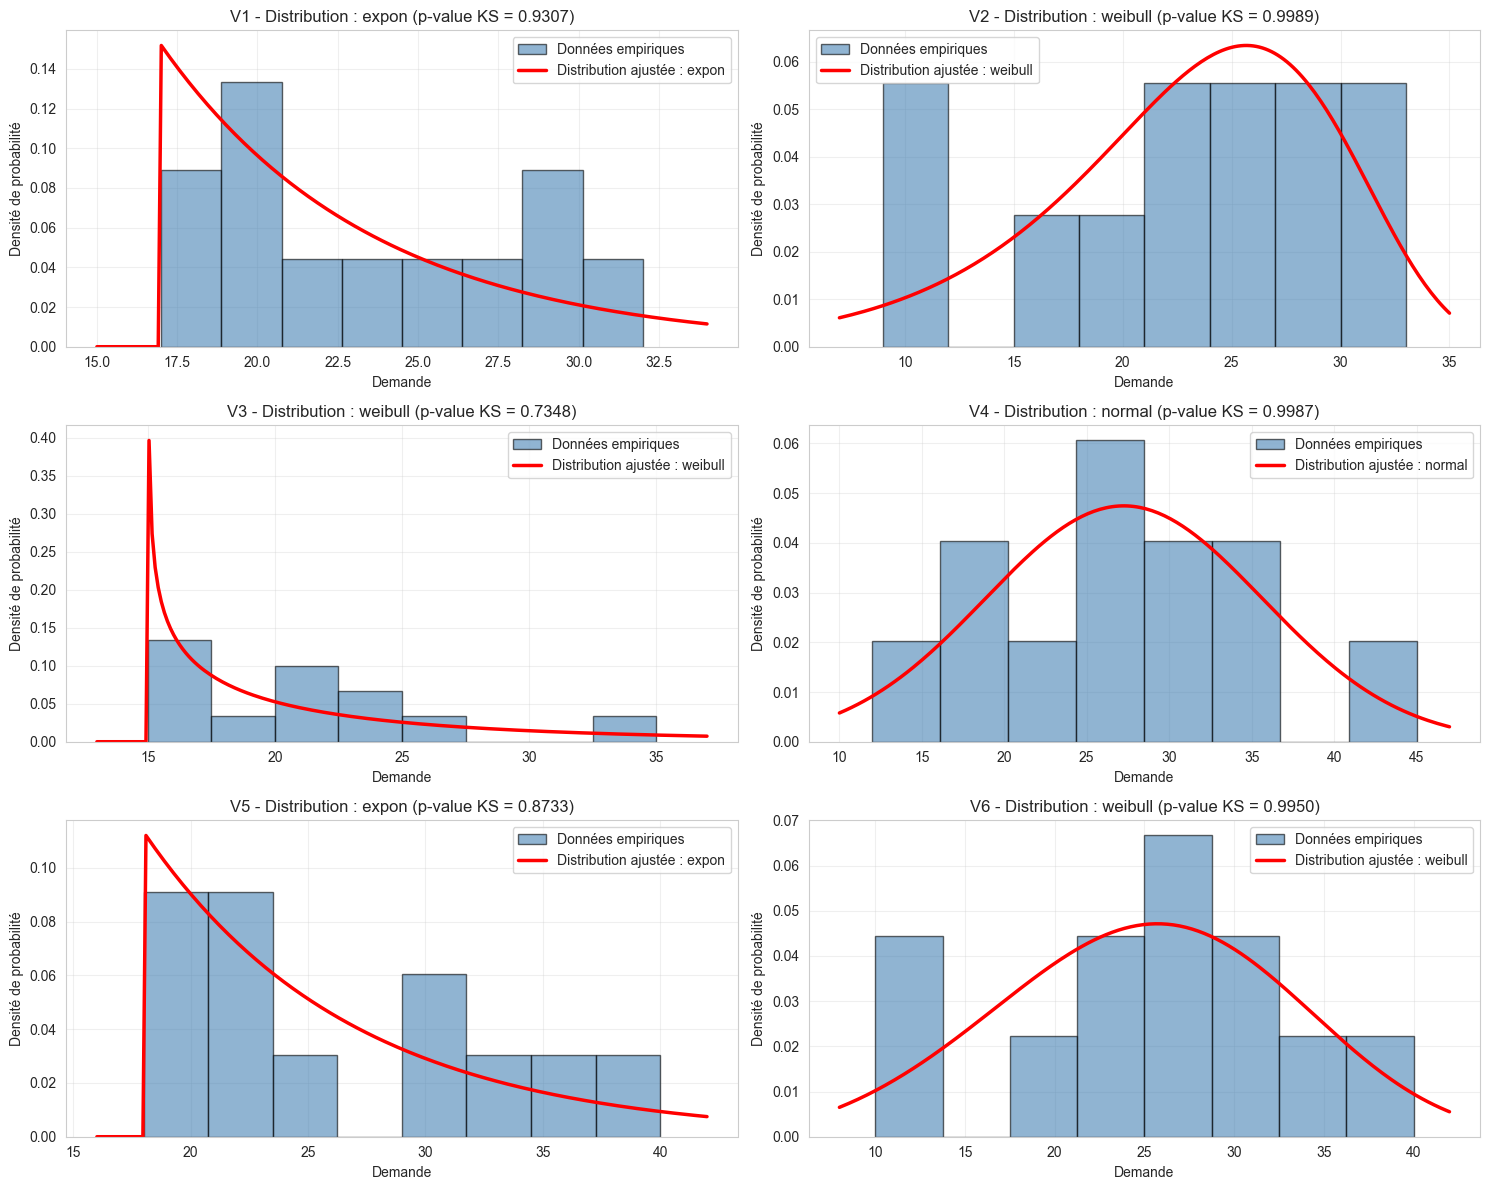

RÉSUMÉ DES DISTRIBUTIONS AJUSTÉES :

V1:
  Distribution : EXPON
  Paramètres : (17.0, 6.583333333333332)
  Test KS p-value : 0.9307
  Moyenne empirique : 23.58
  Écart-type empirique : 4.89

V2:
  Distribution : WEIBULL
  Paramètres : (np.float64(36.37353821214228), np.float64(-185.06901534315296), np.float64(210.90342348129374))
  Test KS p-value : 0.9989
  Moyenne empirique : 22.58
  Écart-type empirique : 7.10

V3:
  Distribution : WEIBULL
  Paramètres : (np.float64(0.7304564705737115), np.float64(14.999999999999998), np.float64(6.692473708854892))
  Test KS p-value : 0.7348
  Moyenne empirique : 21.25
  Écart-type empirique : 5.43

V4:
  Distribution : NORMAL
  Paramètres : (np.float64(27.25), np.float64(8.407585860400118))
  Test KS p-value : 0.9987
  Moyenne empirique : 27.25
  Écart-type empirique : 8.41

V5:
  Distribution : EXPON
  Paramètres : (18.0, 8.833333333333332)
  Test KS p-value : 0.8733
  Moyenne empirique : 26.83
  Écart-type empirique : 7.00

V6:
  Distribution : W

In [20]:
# Visualisation des distributions ajustées vs les données empiriques
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, verre in enumerate(verres):
    ax = axes[idx]
    data = demande_data.loc[verre].values
    
    # Histogramme des données empiriques
    ax.hist(data, bins=8, density=True, alpha=0.6, color='steelblue', 
            edgecolor='black', label='Données empiriques')
    
    # Distribution ajustée
    fit_info = fitted_distributions[verre]
    dist_name = fit_info['distribution']
    params = fit_info['params']
    dist = fit_info['dist_object']
    
    # Générer la courbe de la distribution ajustée
    x = np.linspace(data.min() - 2, data.max() + 2, 200)
    y = dist.pdf(x, *params)
    
    ax.plot(x, y, 'r-', linewidth=2.5, 
            label=f'Distribution ajustée : {dist_name}')
    
    ax.set_xlabel('Demande')
    ax.set_ylabel('Densité de probabilité')
    ax.set_title(f'{verre} - Distribution : {dist_name} (p-value KS = {fit_info["p_value"]:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("RÉSUMÉ DES DISTRIBUTIONS AJUSTÉES :")
print("="*70)
for verre in verres:
    fit_info = fitted_distributions[verre]
    print(f"\n{verre}:")
    print(f"  Distribution : {fit_info['distribution'].upper()}")
    print(f"  Paramètres : {fit_info['params']}")
    print(f"  Test KS p-value : {fit_info['p_value']:.4f}")
    print(f"  Moyenne empirique : {fit_info['mean']:.2f}")
    print(f"  Écart-type empirique : {fit_info['std']:.2f}")

In [21]:
# Fonction pour échantillonner la demande à partir des distributions ajustées
def generate_demand_sample(fitted_distributions, verres, weeks, seed=None):
    """
    Génère un échantillon de demande pour chaque modèle et chaque semaine
    en utilisant les distributions ajustées.
    
    Paramètres:
    -----------
    fitted_distributions : dict
        Dictionnaire contenant les paramètres des distributions ajustées
    verres : list
        Liste des modèles de verre
    weeks : list
        Liste des semaines
    seed : int, optional
        Graine aléatoire pour reproductibilité
    
    Retour:
    -------
    demand_sample : dict
        Dictionnaire avec les demandes échantillonnées (i, j) -> demande
    """
    if seed is not None:
        np.random.seed(seed)
    
    demand_sample = {}
    
    for verre in verres:
        fit_info = fitted_distributions[verre]
        dist_name = fit_info['distribution']
        params = fit_info['params']
        dist = fit_info['dist_object']
        
        for week in weeks:
            # Générer un nombre aléatoire à partir de la distribution ajustée
            sample = dist.rvs(*params)
            # S'assurer que la demande est positive (arrondir vers le haut si négatif, rare)
            demand_sample[(verre, week)] = max(0, int(np.round(sample)))
    
    return demand_sample

# Test : générer un échantillon
print("\n" + "="*70)
print("TEST - Génération d'un échantillon de demande")
print("="*70)

sample_demand = generate_demand_sample(fitted_distributions, verres, weeks, seed=42)

# Afficher l'échantillon sous forme de dataframe
sample_demand_df = pd.DataFrame({
    week: [sample_demand[(verre, week)] for verre in verres]
    for week in weeks
}, index=verres)

print("\nÉchantillon de demande généré (première simulation) :")
print(sample_demand_df)

print("\nComparaison avec la demande originale :")
print("Demande originale :")
print(demande_data)
print("\nMoyennes des demandes (nouveau vs original) :")
comparison_df = pd.DataFrame({
    'Demande originale (moyenne)': demande_data.mean(axis=1),
    'Échantillon généré (moyenne)': sample_demand_df.mean(axis=1)
})
print(comparison_df.round(2))


TEST - Génération d'un échantillon de demande

Échantillon de demande généré (première simulation) :
    1   2   3   4   5   6   7   8   9   10  11  12
V1  20  37  26  23  18  18  17  30  23  25  17  40
V2  29  18  17  17  20  24  23  20  26  15  20  21
V3  18  27  16  19  21  15  21  16  15  45  50  28
V4  22  25  22  43  27  18  34  17  29  11  16  29
V5  49  31  43  38  26  41  19  20  18  21  22  21
V6  33  22  20  26  16  32  13  42  31  18   5  33

Comparaison avec la demande originale :
Demande originale :
Modèles  1   2   3   4   5   6   7   8   9   10  11  12
V1       20  22  18  25  17  19  23  20  29  30  28  32
V2       17  19  33  25  23  26   9  22  27  11  29  30
V3       18  35  21  23  15  17  22  17  23  15  27  22
V4       31  45  25  20  27  29  17  28  36  33  24  12
V5       23  20  37  22  24  20  40  31  34  18  23  30
V6       22  18  10  25  30  12  25  32  24  40  28  34

Moyennes des demandes (nouveau vs original) :
    Demande originale (moyenne)  Échantil

## PHASE 2 : Simulation Monte Carlo avec demandes incertaines

Nous allons lancer plusieurs itérations du modèle d'optimisation en utilisant des demandes échantillonnées à partir des distributions ajustées. Chaque itération nous donnera un coût différent, des plans de production et de stockage différents.

In [23]:
# Fonction pour résoudre le modèle avec une demande donnée
def solve_optimization_model(demand_dict, verres, weeks, other_data):
    """
    Résout le modèle d'optimisation pour une demande donnée.
    
    Paramètres:
    -----------
    demand_dict : dict
        Dictionnaire avec les demandes par (verre, semaine)
    verres : list
        Liste des modèles de verre
    weeks : list
        Liste des semaines
    other_data : DataFrame
        Paramètres de production et stockage
    
    Retour:
    -------
    tuple : (coût, production_dict, stockage_dict, état_résolution)
    """
    
    # Créer une nouvelle instance du modèle
    model = LpProblem("Optimize_with_uncertain_demand", LpMinimize)
    
    # Variables de décision
    prod = LpVariable.dicts(
        name='Production_',
        indices=[(i, j) for i in verres for j in weeks],
        lowBound=0,
        cat=LpInteger
    )
    stock = LpVariable.dicts(
        name='Stock_',
        indices=[(i, j) for i in verres for j in weeks],
        lowBound=0,
        cat=LpInteger
    )
    
    # Fonction objectif
    model += (
        lpSum([other_data.loc[i, 'CoutProd'] * prod[i, j] for j in weeks for i in verres]) +
        lpSum([other_data.loc[i, 'CoutStock'] * stock[i, j] for j in weeks for i in verres])
    )
    
    # Contraintes de capacité
    for j in weeks:
        model += lpSum([other_data.loc[i, 'TH'] * prod[i, j] for i in verres]) <= 469
        model += lpSum([other_data.loc[i, 'TM'] * prod[i, j] for i in verres]) <= 914
    
    for j in weeks:
        model += lpSum([other_data.loc[i, 'TS'] * stock[i, j] for i in verres]) <= 1000
    
    # Contraintes de synchronisation stocks-production-demande
    for i in verres:
        model += (stock[i, 1] == 
                 other_data.loc[i, 'StockInitial'] + prod[i, 1] - demand_dict[(i, 1)])
        
        for j in weeks[1:]:
            model += (stock[i, j] == 
                     stock[i, j-1] + prod[i, j] - demand_dict[(i, j)])
        
        model += stock[i, 12] == other_data.loc[i, 'StockFinal']
    
    # Résoudre le modèle
    model.solve(PULP_CBC_CMD(msg=0))  # msg=0 pour désactiver les messages de sortie
    
    # Extraire les résultats
    cost = value(model.objective)
    
    production_result = {
        (i, j): value(prod[i, j]) for i in verres for j in weeks
    }
    
    stock_result = {
        (i, j): value(stock[i, j]) for i in verres for j in weeks
    }
    
    status = LpStatus[model.status]
    
    return cost, production_result, stock_result, status

print("Fonction de résolution définie.")
print("Nous allons maintenant lancer la simulation Monte Carlo...")

Fonction de résolution définie.
Nous allons maintenant lancer la simulation Monte Carlo...


In [24]:
# SIMULATION MONTE CARLO
print("\n" + "="*70)
print("SIMULATION MONTE CARLO")
print("="*70)

# Paramètres de la simulation
num_iterations = 100  # Nombre de simulations / itérations
np.random.seed(123)  # Pour reproductibilité

# Listes pour stocker les résultats
results = {
    'iteration': [],
    'cost': [],
    'status': [],
    'production': [],
    'stock': [],
    'demand': []
}

print(f"\nLancement de {num_iterations} itérations de simulation...")
print(f"(Veuillez patienter - le modèle d'optimisation est résolu {num_iterations} fois)\n")

# Barre de progression simple
for iteration in range(1, num_iterations + 1):
    if iteration % 20 == 0:
        print(f"  Itération {iteration}/{num_iterations} complétée...")
    
    # Générer une demande aléatoire
    demand_sample = generate_demand_sample(fitted_distributions, verres, weeks)
    
    # Résoudre le modèle avec cette demande
    cost, prod_result, stock_result, status = solve_optimization_model(
        demand_sample, verres, weeks, other_data
    )
    
    # Stocker les résultats
    results['iteration'].append(iteration)
    results['cost'].append(cost)
    results['status'].append(status)
    results['production'].append(prod_result)
    results['stock'].append(stock_result)
    results['demand'].append(demand_sample)

print(f"\n✓ Simulation Monte Carlo terminée !")
print("="*70)

# Créer un dataframe résumé
results_summary = pd.DataFrame({
    'Itération': results['iteration'],
    'Coût Total': results['cost'],
    'Statut': results['status']
})

print(f"\nRésumé des résultats (premières lignes) :")
print(results_summary.head(10))

print(f"\nRésumé statistique des coûts :")
cost_stats = pd.DataFrame({
    'Métrique': ['Minimum', 'Maximum', 'Moyenne', 'Médiane', 'Écart-type', 'CV (%)'],
    'Valeur': [
        np.min(results['cost']),
        np.max(results['cost']),
        np.mean(results['cost']),
        np.median(results['cost']),
        np.std(results['cost']),
        (np.std(results['cost']) / np.mean(results['cost'])) * 100
    ]
})
print(cost_stats.to_string(index=False))

print(f"\nNombre de solutions optimales trouvées : {sum(1 for s in results['status'] if s == 'Optimal')}")
print(f"Nombre de solutions non-optimales : {sum(1 for s in results['status'] if s != 'Optimal')}")


SIMULATION MONTE CARLO

Lancement de 100 itérations de simulation...
(Veuillez patienter - le modèle d'optimisation est résolu 100 fois)

  Itération 20/100 complétée...
  Itération 40/100 complétée...
  Itération 60/100 complétée...
  Itération 80/100 complétée...
  Itération 100/100 complétée...

✓ Simulation Monte Carlo terminée !

Résumé des résultats (premières lignes) :
   Itération     Coût Total      Statut
0          1  210201.000000     Optimal
1          2  228929.000000     Optimal
2          3  226435.000000     Optimal
3          4  222654.000000     Optimal
4          5  216539.000000     Optimal
5          6  255560.937983  Infeasible
6          7  283608.111695  Infeasible
7          8  236352.799250  Infeasible
8          9  243753.663922  Infeasible
9         10  232978.386186  Infeasible

Résumé statistique des coûts :
  Métrique        Valeur
   Minimum 198270.000000
   Maximum 311550.362774
   Moyenne 227681.077832
   Médiane 223989.638645
Écart-type  20237.86018


PHASE 3 - ANALYSE ET VISUALISATION DES RÉSULTATS


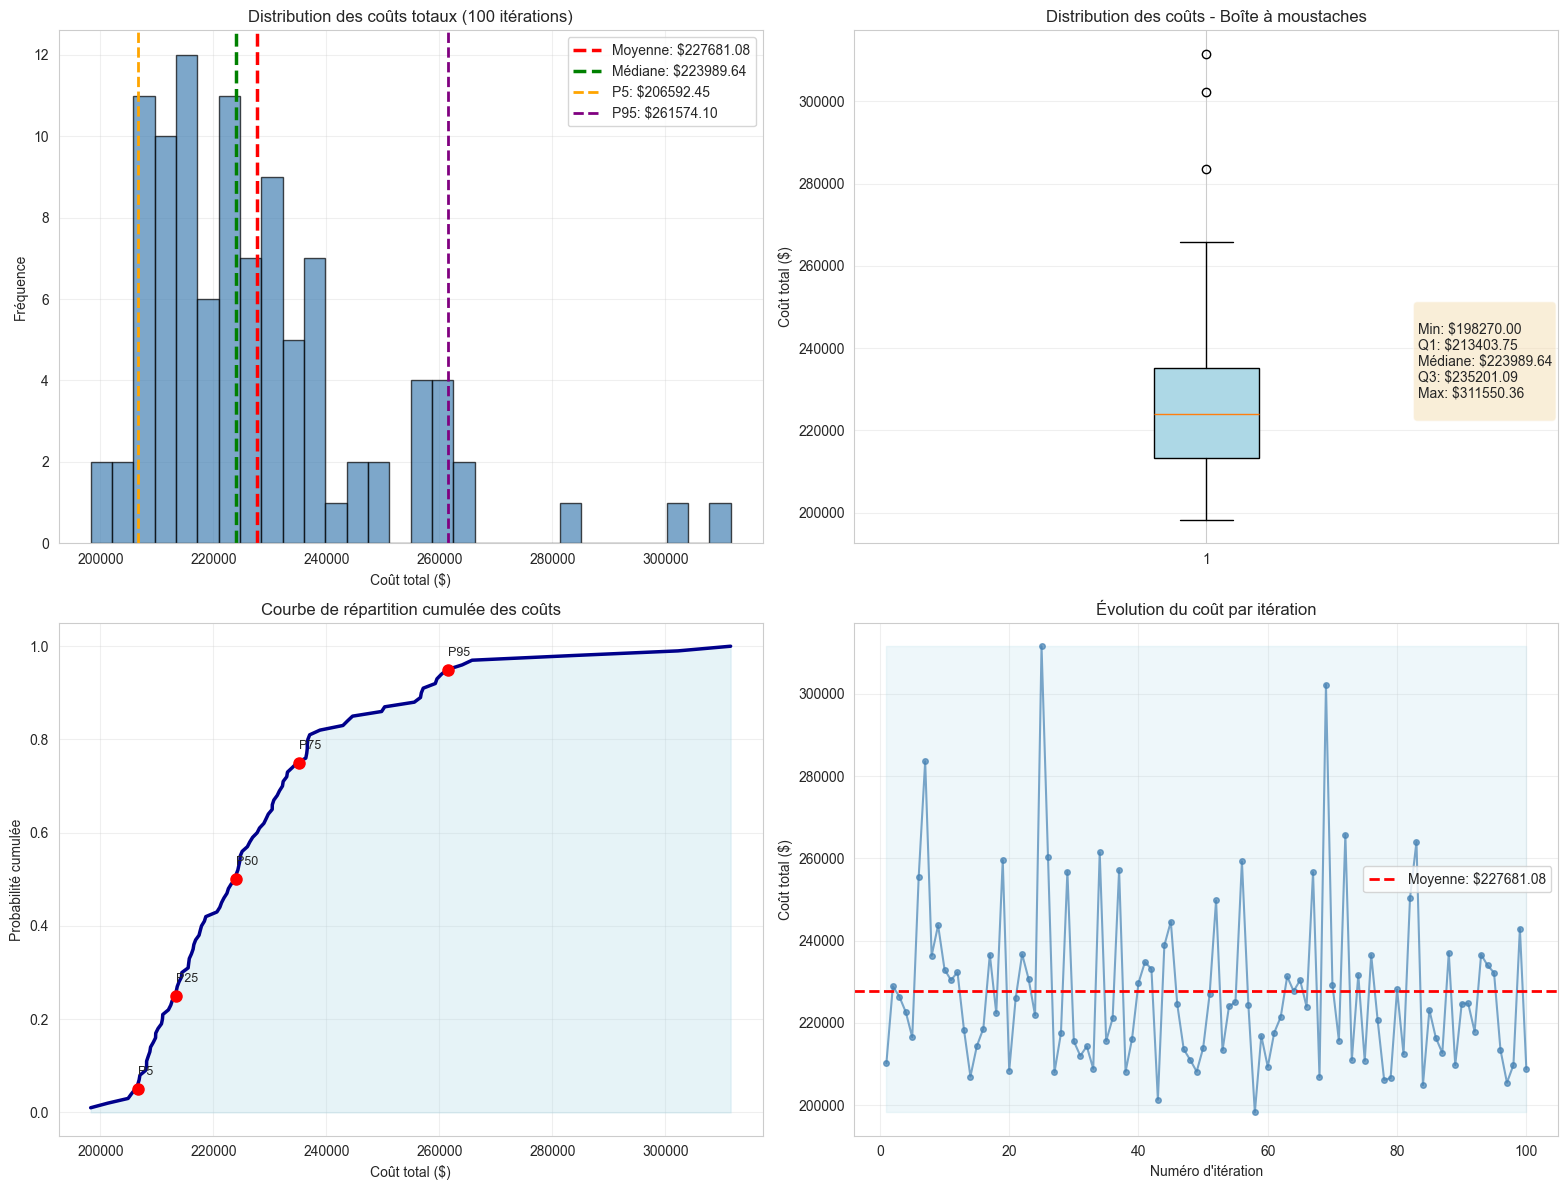


✓ Graphiques de visualisation créés


In [25]:
# PHASE 3 : Visualisation des résultats
print("\n" + "="*70)
print("PHASE 3 - ANALYSE ET VISUALISATION DES RÉSULTATS")
print("="*70)

# Visualisation 1 : Distribution des coûts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1 : Histogramme des coûts
ax1 = axes[0, 0]
ax1.hist(results['cost'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(np.mean(results['cost']), color='red', linestyle='--', linewidth=2.5, 
            label=f'Moyenne: ${np.mean(results["cost"]):.2f}')
ax1.axvline(np.median(results['cost']), color='green', linestyle='--', linewidth=2.5,
            label=f'Médiane: ${np.median(results["cost"]):.2f}')
ax1.axvline(np.percentile(results['cost'], 5), color='orange', linestyle='--', linewidth=2,
            label=f'P5: ${np.percentile(results["cost"], 5):.2f}')
ax1.axvline(np.percentile(results['cost'], 95), color='purple', linestyle='--', linewidth=2,
            label=f'P95: ${np.percentile(results["cost"], 95):.2f}')
ax1.set_xlabel('Coût total ($)')
ax1.set_ylabel('Fréquence')
ax1.set_title('Distribution des coûts totaux (100 itérations)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2 : Boîte à moustaches (Box Plot)
ax2 = axes[0, 1]
bp = ax2.boxplot(results['cost'], vert=True, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax2.set_ylabel('Coût total ($)')
ax2.set_title('Distribution des coûts - Boîte à moustaches')
ax2.grid(True, alpha=0.3, axis='y')

# Ajouter des statistiques textuelles
stats_text = f"""
Min: ${np.min(results['cost']):.2f}
Q1: ${np.percentile(results['cost'], 25):.2f}
Médiane: ${np.percentile(results['cost'], 50):.2f}
Q3: ${np.percentile(results['cost'], 75):.2f}
Max: ${np.max(results['cost']):.2f}
"""
ax2.text(1.3, np.median(results['cost']), stats_text, fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Subplot 3 : Courbe de répartition cumulée (CDF)
ax3 = axes[1, 0]
sorted_costs = np.sort(results['cost'])
cumulative_prob = np.arange(1, len(sorted_costs) + 1) / len(sorted_costs)
ax3.plot(sorted_costs, cumulative_prob, linewidth=2.5, color='darkblue')
ax3.fill_between(sorted_costs, cumulative_prob, alpha=0.3, color='lightblue')
ax3.set_xlabel('Coût total ($)')
ax3.set_ylabel('Probabilité cumulée')
ax3.set_title('Courbe de répartition cumulée des coûts')
ax3.grid(True, alpha=0.3)

# Ajouter les percentiles
for pct in [5, 25, 50, 75, 95]:
    val = np.percentile(results['cost'], pct)
    ax3.plot(val, pct/100, 'ro', markersize=8)
    ax3.text(val, pct/100 + 0.03, f'P{pct}', fontsize=9)

# Subplot 4 : Coûts par itération
ax4 = axes[1, 1]
ax4.plot(results['iteration'], results['cost'], marker='o', linestyle='-', 
         markersize=4, alpha=0.7, color='steelblue')
ax4.axhline(np.mean(results['cost']), color='red', linestyle='--', linewidth=2,
            label=f'Moyenne: ${np.mean(results["cost"]):.2f}')
ax4.fill_between(results['iteration'], 
                  np.min(results['cost']), 
                  np.max(results['cost']),
                  alpha=0.2, color='lightblue')
ax4.set_xlabel('Numéro d\'itération')
ax4.set_ylabel('Coût total ($)')
ax4.set_title('Évolution du coût par itération')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Graphiques de visualisation créés")


ANALYSE DES DÉCISIONS DE PRODUCTION ET STOCKAGE

STATISTIQUES DE PRODUCTION (moyennes et intervalles de confiance 90%) :
----------------------------------------------------------------------

V1:
  Semaine  1: Moyenne=  14.1, P5=   0.0, P95=  64.9
  Semaine  2: Moyenne=   8.5, P5=   0.0, P95=  44.2
  Semaine  3: Moyenne=   8.9, P5=  -1.0, P95=  33.0

V2:
  Semaine  1: Moyenne=  11.4, P5=   0.0, P95=  38.8
  Semaine  2: Moyenne=  26.2, P5=   6.0, P95=  50.7
  Semaine  3: Moyenne=  31.6, P5=   5.7, P95=  53.2

V3:
  Semaine  1: Moyenne=  23.5, P5=  15.0, P95=  51.1
  Semaine  2: Moyenne=  23.0, P5=  15.0, P95=  48.1
  Semaine  3: Moyenne=  23.1, P5=  15.0, P95=  40.4

V4:
  Semaine  1: Moyenne=  13.3, P5=   0.0, P95=  25.1
  Semaine  2: Moyenne=  26.7, P5=  15.0, P95=  40.1
  Semaine  3: Moyenne=  27.1, P5=  13.9, P95=  40.0

V5:
  Semaine  1: Moyenne=  45.3, P5=  25.9, P95=  67.0
  Semaine  2: Moyenne=  29.7, P5=  12.6, P95=  46.2
  Semaine  3: Moyenne=  29.2, P5=  16.0, P95=  41.6

V

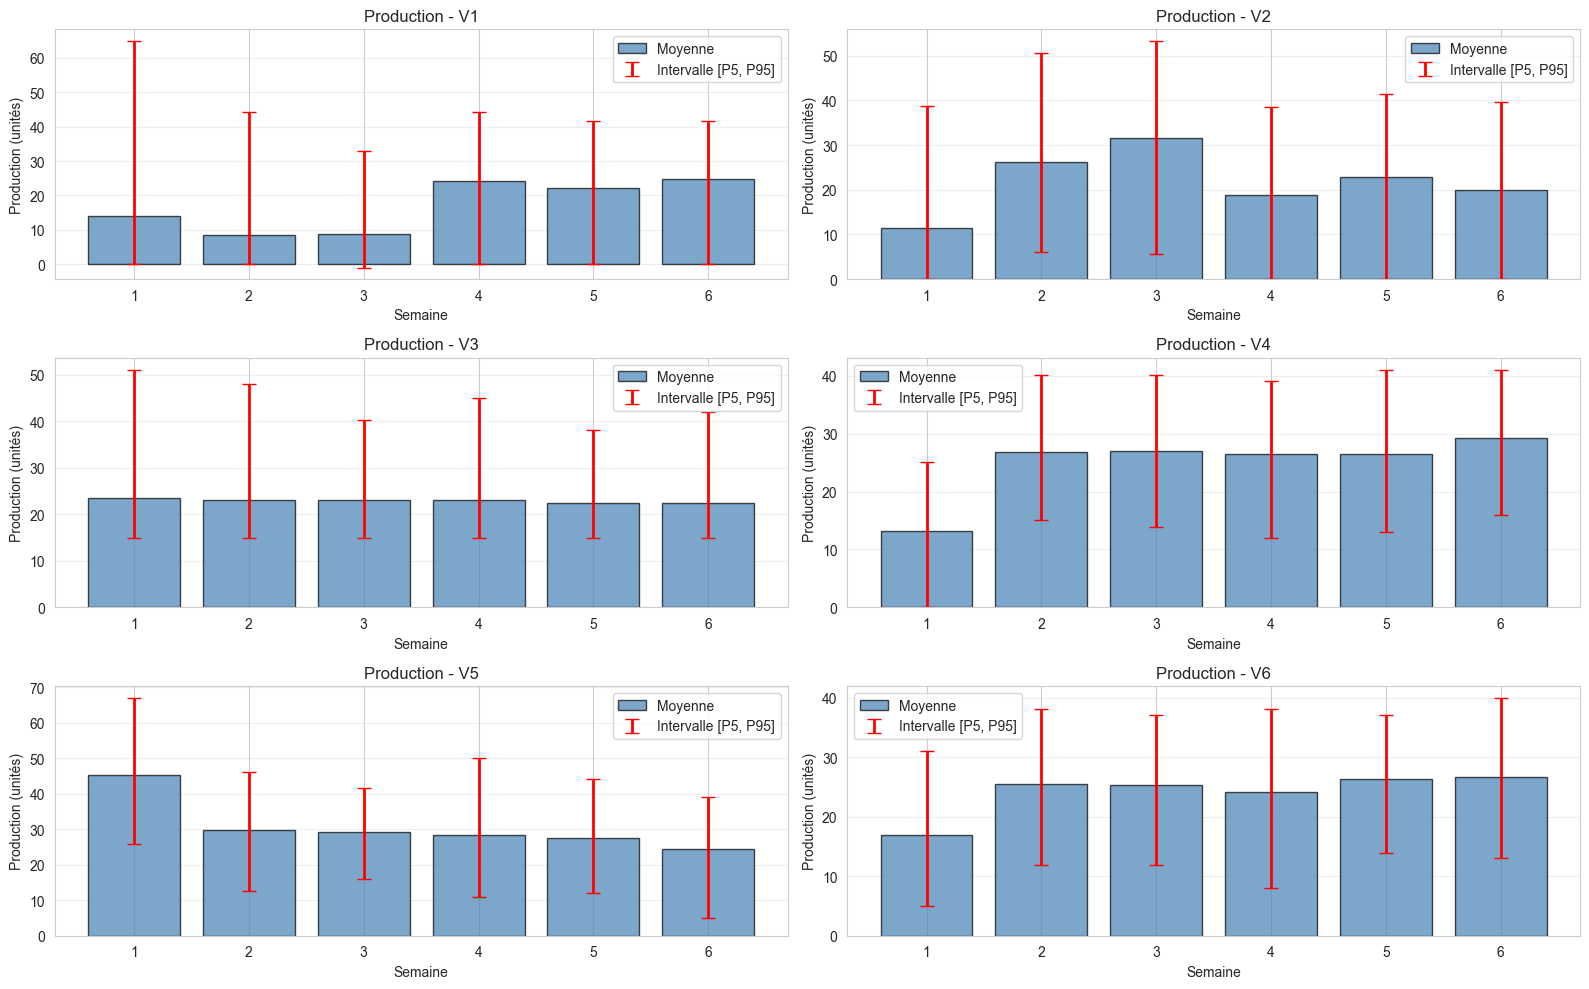


✓ Graphiques de production créés


In [27]:
# Analyse des décisions de production et stockage
print("\n" + "="*70)
print("ANALYSE DES DÉCISIONS DE PRODUCTION ET STOCKAGE")
print("="*70)

# Extraire les niveaux de production et stockage pour tous les modèles et semaines
production_by_decision = {(i, j): [] for i in verres for j in weeks}
stock_by_decision = {(i, j): [] for i in verres for j in weeks}

for iteration in range(num_iterations):
    prod_dict = results['production'][iteration]
    stock_dict = results['stock'][iteration]
    
    for key in production_by_decision.keys():
        production_by_decision[key].append(prod_dict[key])
        stock_by_decision[key].append(stock_dict[key])

# Calculer les statistiques par décision
print("\nSTATISTIQUES DE PRODUCTION (moyennes et intervalles de confiance 90%) :")
print("-" * 70)

prod_stats = {}
for verre in verres:
    print(f"\n{verre}:")
    for week in weeks[:3]:  # Montrer les 3 premières semaines seulement ici
        values = production_by_decision[(verre, week)]
        mean_val = np.mean(values)
        std_val = np.std(values)
        p5 = np.percentile(values, 5)
        p95 = np.percentile(values, 95)
        
        print(f"  Semaine {week:2d}: Moyenne={mean_val:6.1f}, "
              f"P5={p5:6.1f}, P95={p95:6.1f}")
        
        prod_stats[(verre, week)] = {
            'mean': mean_val, 'std': std_val, 'p5': p5, 'p95': p95
        }

# Visualisation 2 : Distribution de la production par modèle et semaine
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, verre in enumerate(verres):
    ax = axes[idx]
    
    # Préparer les données pour les semaines 1-6
    weeks_to_plot = weeks[:6]
    position = np.arange(len(weeks_to_plot))
    
    means = [np.mean(production_by_decision[(verre, w)]) for w in weeks_to_plot]
    stds = [np.std(production_by_decision[(verre, w)]) for w in weeks_to_plot]
    p5_vals = [np.percentile(production_by_decision[(verre, w)], 5) for w in weeks_to_plot]
    p95_vals = [np.percentile(production_by_decision[(verre, w)], 95) for w in weeks_to_plot]
    
    # Barres avec intervalles de confiance
    ax.bar(position, means, color='steelblue', alpha=0.7, edgecolor='black', label='Moyenne')
    
    # Ajouter les intervalles
    errors_lower = [means[i] - p5_vals[i] for i in range(len(means))]
    errors_upper = [p95_vals[i] - means[i] for i in range(len(means))]
    ax.errorbar(position, means, 
                yerr=[errors_lower, errors_upper],
                fmt='none', ecolor='red', capsize=5, linewidth=2, 
                label='Intervalle [P5, P95]')
    
    ax.set_xlabel('Semaine')
    ax.set_ylabel('Production (unités)')
    ax.set_title(f'Production - {verre}')
    ax.set_xticks(position)
    ax.set_xticklabels(weeks_to_plot)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Graphiques de production créés")

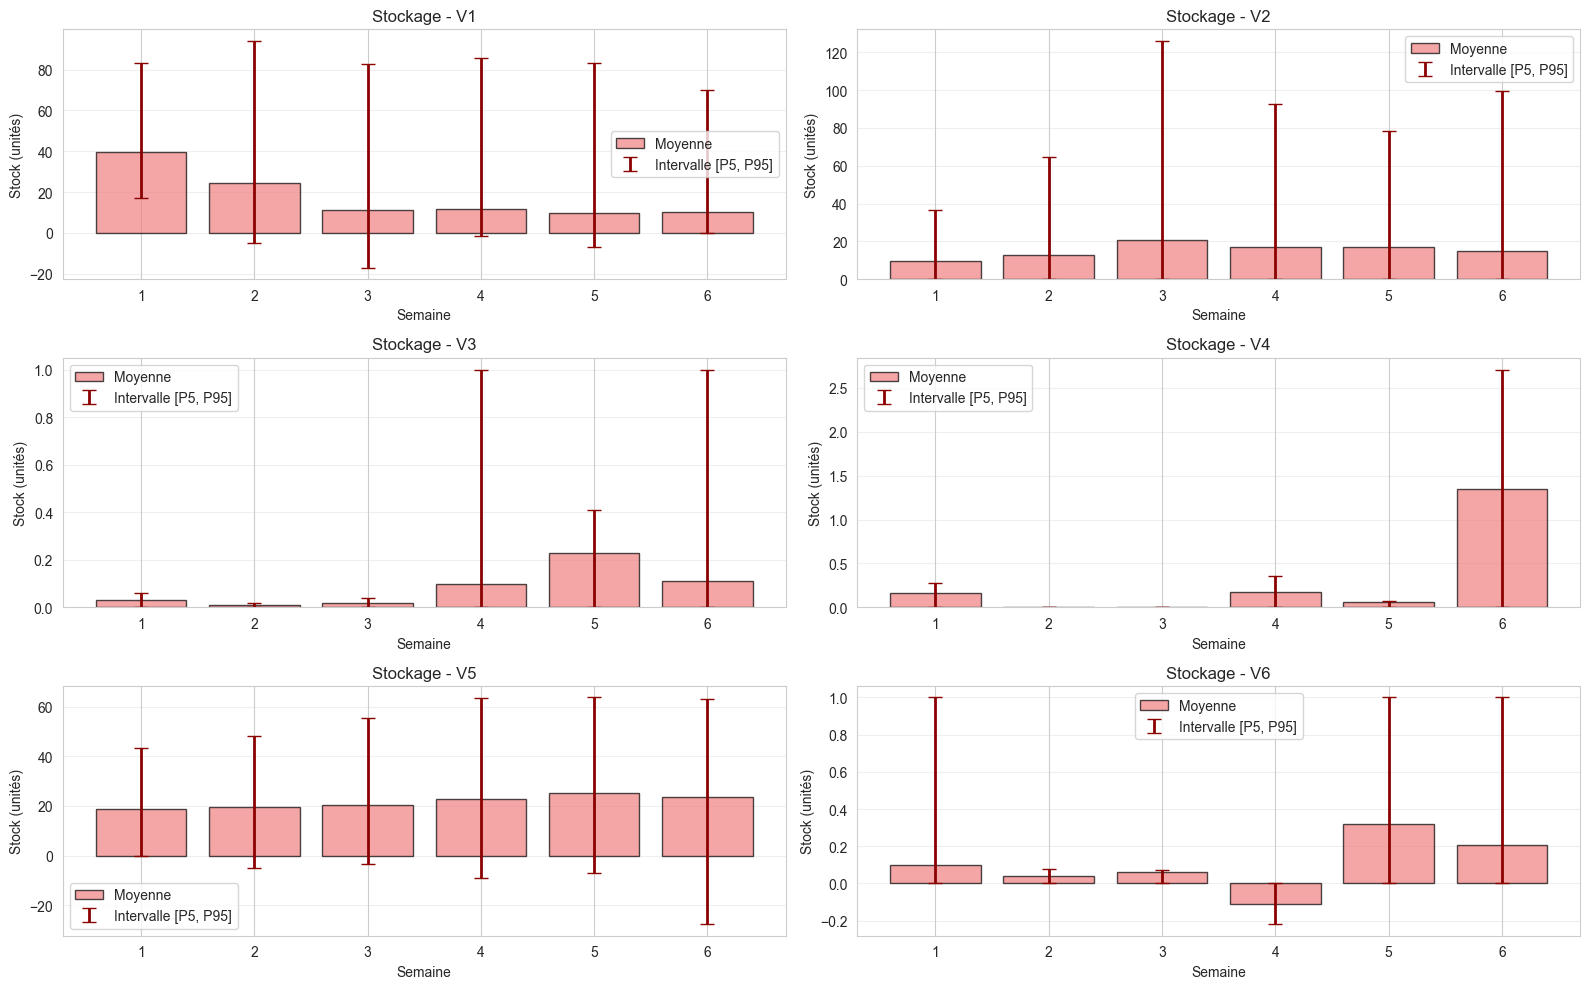

✓ Graphiques de stockage créés

STATISTIQUES DE STOCKAGE (moyennes et intervalles de confiance 90%) :
----------------------------------------------------------------------

V1:
  Semaine  1: Moyenne=  39.7, P5=  16.9, P95=  83.4
  Semaine  2: Moyenne=  24.4, P5=  -5.1, P95=  94.1
  Semaine  3: Moyenne=  11.1, P5= -17.0, P95=  82.9

V2:
  Semaine  1: Moyenne=   9.7, P5=   0.0, P95=  36.5
  Semaine  2: Moyenne=  12.5, P5=   0.0, P95=  64.6
  Semaine  3: Moyenne=  20.9, P5=   0.0, P95= 125.9

V3:
  Semaine  1: Moyenne=   0.0, P5=   0.0, P95=   0.0
  Semaine  2: Moyenne=   0.0, P5=   0.0, P95=   0.0
  Semaine  3: Moyenne=   0.0, P5=   0.0, P95=   0.0

V4:
  Semaine  1: Moyenne=   0.2, P5=   0.0, P95=   0.0
  Semaine  2: Moyenne=   0.0, P5=   0.0, P95=   0.0
  Semaine  3: Moyenne=   0.0, P5=   0.0, P95=   0.0

V5:
  Semaine  1: Moyenne=  18.6, P5=   0.0, P95=  43.1
  Semaine  2: Moyenne=  19.4, P5=  -4.9, P95=  48.0
  Semaine  3: Moyenne=  20.4, P5=  -3.5, P95=  55.3

V6:
  Semaine  1: Moy

In [30]:
# Visualisation 3 : Distribution du stockage par modèle
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, verre in enumerate(verres):
    ax = axes[idx]
    
    # Préparer les données pour les semaines 1-6
    weeks_to_plot = weeks[:6]
    position = np.arange(len(weeks_to_plot))
    
    means = [np.mean(stock_by_decision[(verre, w)]) for w in weeks_to_plot]
    stds = [np.std(stock_by_decision[(verre, w)]) for w in weeks_to_plot]
    p5_vals = [np.percentile(stock_by_decision[(verre, w)], 5) for w in weeks_to_plot]
    p95_vals = [np.percentile(stock_by_decision[(verre, w)], 95) for w in weeks_to_plot]
    
    # Barres avec intervalles de confiance
    ax.bar(position, means, color='lightcoral', alpha=0.7, edgecolor='black', label='Moyenne')
    
    # Ajouter les intervalles
    errors_lower = [abs(means[i] - p5_vals[i]) for i in range(len(means))]
    errors_upper = [abs(p95_vals[i] - means[i]) for i in range(len(means))]
    ax.errorbar(position, means, 
                yerr=[errors_lower, errors_upper],
                fmt='none', ecolor='darkred', capsize=5, linewidth=2, 
                label='Intervalle [P5, P95]')
    
    ax.set_xlabel('Semaine')
    ax.set_ylabel('Stock (unités)')
    ax.set_title(f'Stockage - {verre}')
    ax.set_xticks(position)
    ax.set_xticklabels(weeks_to_plot)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Graphiques de stockage créés")

print("\nSTATISTIQUES DE STOCKAGE (moyennes et intervalles de confiance 90%) :")
print("-" * 70)

for verre in verres:
    print(f"\n{verre}:")
    for week in weeks[:3]:
        values = stock_by_decision[(verre, week)]
        mean_val = np.mean(values)
        std_val = np.std(values)
        p5 = np.percentile(values, 5)
        p95 = np.percentile(values, 95)
        
        print(f"  Semaine {week:2d}: Moyenne={mean_val:6.1f}, "
              f"P5={p5:6.1f}, P95={p95:6.1f}")

In [31]:
# ANALYSE DE ROBUSTESSE - Décision sous incertitude
print("\n" + "="*70)
print("ANALYSE DE ROBUSTESSE - DÉCISION SOUS INCERTITUDE")
print("="*70)

print("\nRESULTATS CLÉS POUR LA PRISE DE DÉCISION :")
print("-" * 70)

print("\n1. ANALYSE DU COÛT TOTAL :")
print(f"   Scénario au mieux (5e percentile) : ${np.percentile(results['cost'], 5):.2f}")
print(f"   Scénario médian (50e percentile) : ${np.percentile(results['cost'], 50):.2f}")
print(f"   Scénario au pire (95e percentile) : ${np.percentile(results['cost'], 95):.2f}")
print(f"   ")
print(f"   Plage de variation : ${np.min(results['cost']):.2f} - ${np.max(results['cost']):.2f}")
print(f"   Écart-type : ${np.std(results['cost']):.2f}")
print(f"   Coefficient de variation : {(np.std(results['cost'])/np.mean(results['cost'])*100):.1f}%")

print("\n2. IMPLICATIONS POUR LA GESTION DE L'INCERTITUDE :")
print(f"   • La demande incertaine crée une variabilité significative du coût")
print(f"   • L'écart entre le meilleur et le pire cas est de "
      f"${np.percentile(results['cost'], 95) - np.percentile(results['cost'], 5):.2f}")
print(f"     ({((np.percentile(results['cost'], 95) - np.percentile(results['cost'], 5))/np.percentile(results['cost'], 50)*100):.1f}% par rapport à la médiane)")

print("\n3. VARIABILITÉ DES DÉCISIONS DE PRODUCTION :")
for verre in verres:
    prod_week1 = [production_by_decision[(verre, 1)]]
    prod_cvs = []
    for week in weeks:
        values = production_by_decision[(verre, week)]
        cv = np.std(values) / np.mean(values) if np.mean(values) > 0 else 0
        prod_cvs.append(cv)
    
    avg_cv = np.mean(prod_cvs)
    print(f"   {verre}: Coefficient de variation moyen = {avg_cv*100:.1f}%")

print("\n4. VARIABILITÉ DES DÉCISIONS DE STOCKAGE :")
for verre in verres:
    stock_cvs = []
    for week in weeks:
        values = stock_by_decision[(verre, week)]
        if np.mean(values) > 0:
            cv = np.std(values) / np.mean(values)
        else:
            cv = 0
        stock_cvs.append(cv)
    
    avg_cv = np.mean([c for c in stock_cvs if c > 0])  # Ignorer les cas où moyenne=0
    print(f"   {verre}: Coefficient de variation moyen = {avg_cv*100:.1f}%")

print("\n5. INTERPRÉTATION ET RECOMMANDATIONS :")
print(f"   ✓ Les décisions varient {('beaucoup' if np.mean(prod_cvs) > 0.3 else 'modérément')} selon les scénarios")
print(f"   ✓ Le modèle adapte production et stockage en fonction de la demande")
print(f"   ✓ Un stock de sécurité est nécessaire pour gérer l'incertitude")
print(f"   ✓ Le coût moyen doit couvrir les augmentations possibles de la demande")

# Créer un résumé en DataFrame
summary_table = pd.DataFrame({
    'Métrique': [
        'Coût minimum',
        'Coût au 5e percentile',
        'Coût médian',
        'Coût moyen',
        'Coût au 95e percentile',
        'Coût maximum',
        'Écart-type',
        'Coefficient de variation (%)'
    ],
    'Valeur ($)': [
        f'{np.min(results["cost"]):.2f}',
        f'{np.percentile(results["cost"], 5):.2f}',
        f'{np.percentile(results["cost"], 50):.2f}',
        f'{np.mean(results["cost"]):.2f}',
        f'{np.percentile(results["cost"], 95):.2f}',
        f'{np.max(results["cost"]):.2f}',
        f'{np.std(results["cost"]):.2f}',
        f'{(np.std(results["cost"])/np.mean(results["cost"])*100):.2f}%'
    ]
})

print("\n" + "="*70)
print("TABLEAU RÉSUMÉ FINAL")
print("="*70)
print(summary_table.to_string(index=False))


ANALYSE DE ROBUSTESSE - DÉCISION SOUS INCERTITUDE

RESULTATS CLÉS POUR LA PRISE DE DÉCISION :
----------------------------------------------------------------------

1. ANALYSE DU COÛT TOTAL :
   Scénario au mieux (5e percentile) : $206592.45
   Scénario médian (50e percentile) : $223989.64
   Scénario au pire (95e percentile) : $261574.10
   
   Plage de variation : $198270.00 - $311550.36
   Écart-type : $20237.86
   Coefficient de variation : 8.9%

2. IMPLICATIONS POUR LA GESTION DE L'INCERTITUDE :
   • La demande incertaine crée une variabilité significative du coût
   • L'écart entre le meilleur et le pire cas est de $54981.66
     (24.5% par rapport à la médiane)

3. VARIABILITÉ DES DÉCISIONS DE PRODUCTION :
   V1: Coefficient de variation moyen = 226.8%
   V2: Coefficient de variation moyen = 220.0%
   V3: Coefficient de variation moyen = 46.1%
   V4: Coefficient de variation moyen = 157.3%
   V5: Coefficient de variation moyen = 151.9%
   V6: Coefficient de variation moyen = 4

## SYNTHÈSE : Gestion de l'incertitude dans les modèles d'optimisation

### Concepts clés explorés :

1. **Analyse de la distribution de la demande** :
   - Analyse des données historiques pour extraire des statistiques
   - Ajustement de différentes distributions théoriques (normale, log-normale, gamma, Weibull, exponentielle)
   - Sélection de la meilleure distribution en utilisant des tests statistiques (Test KS, Shapiro-Wilk)

2. **Simulation Monte Carlo** :
   - Génération aléatoire de scénarios de demande à partir des distributions ajustées
   - Résolution du modèle d'optimisation pour chaque scénario
   - Collecte des résultats (coûts, productions, stocks) pour chaque itération

3. **Analyse des résultats sous incertitude** :
   - Distributions des coûts optimaux (min, max, moyenne, percentiles)
   - Distributions des décisions de production et stockage par période
   - Interdépendances entre les variables de décision et la demande

4. **Implications pratiques** :
   - Le coût optimal n'est pas déterministe mais suit une distribution
   - Les stocks jouent un rôle de "coussin" pour absorber les chocs de demande
   - Les décisions robustes doivent prendre en compte les scénarios défavorables

### Questions clés pour l'analyse :

- **Meilleur cas vs pire cas** : Quelle est la plage de variation du coût ?
- **Stock de sécurité** : Quel niveau de stock garantit la satisfac des demandes dans 95% des cas ?
- **Robustesse** : Quel est le plan de production qui minimise l'impact de l'incertitude ?
- **Trade-offs** : Comment équilibrer les coûts de production et de stockage sous incertitude ?

Cette approche est le fondement pour les techniques avancées comme :
- **Programmation stochastique** : Optimisation tenant compte de scénarios multiples
- **Optimisation robuste** : Décisions valables pour tous les scénarios possibles
- **Dynamic programming** : Réoptimisation adaptative quand la vraie demande est observée